# 01 - Process Rosbags for Training Data

**RAPP Lab 04 - Vision-Action Model**

This notebook processes rosbag recordings to extract and prepare training data:

1. **Extract Topics:** Load skeleton tracking and joint state data
2. **Synchronize:** Align messages by timestamp (interpolate joint states to skeleton rate)
3. **Interactive Selection:** Choose which skeleton is the "leader" with 3D visualization
4. **Transform:** Convert skeleton to robot base coordinate frame
5. **Quality Checks:** Validate tracking confidence, detect position jumps, check joint limits
6. **Export CSV:** Save synchronized data for training
7. **Update Metadata:** Track processed recordings

---

**MANUAL CONFIGURATION:** Set the rosbag name below for each processing run.

In [36]:
# =============================================================================
# MANUAL CONFIGURATION - Change this for each rosbag
# =============================================================================

ROSBAG_NAME = '26_04_03_RAPP_M_R2G2_02'  # <-- CHANGE THIS FOR EACH ROSBAG

# =============================================================================
# Do not modify below this line
# =============================================================================

## 1. Imports and Setup

In [37]:
import os
import sys
from pathlib import Path

# Ensure vam_utils is importable
workspace_dir = Path('/workspace')
if str(workspace_dir) not in sys.path:
    sys.path.insert(0, str(workspace_dir))

import numpy as np
import pandas as pd
import sqlite3
from typing import Optional, Tuple, List, Dict, Any
from datetime import datetime
import yaml

# ROS2 message deserialization
from rclpy.serialization import deserialize_message
from sensor_msgs.msg import JointState
from builtin_interfaces.msg import Time

# For skeleton messages - we'll need to handle this
import importlib.util

# Visualization
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load URDF for FK
from urdf_parser_py.urdf import URDF


# Interactive widgets
from ipywidgets import interact, IntSlider, Layout
print("Imports successful!")

Imports successful!


In [38]:
# Configuration paths
ROSBAG_DIR = Path('/data/rosbags')
PROCESSED_DIR = Path('/data/processed')
CONFIG_DIR = Path('/config')

# Construct full path to rosbag database
rosbag_path = ROSBAG_DIR / ROSBAG_NAME
db_file = list(rosbag_path.glob('*.db3'))[0] if rosbag_path.exists() else None

# Output paths
csv_output_dir = PROCESSED_DIR / 'csv'
csv_output_dir.mkdir(parents=True, exist_ok=True)

metadata_file = PROCESSED_DIR / 'recordings_metadata.csv'

print(f"Rosbag directory: {rosbag_path}")
print(f"Database file: {db_file}")
print(f"CSV output directory: {csv_output_dir}")
print(f"Metadata file: {metadata_file}")

# Verify paths
assert rosbag_path.exists(), f"Rosbag directory not found: {rosbag_path}"
assert db_file is not None and db_file.exists(), f"No .db3 file found in {rosbag_path}"

Rosbag directory: /data/rosbags/26_04_03_RAPP_M_R2G2_02
Database file: /data/rosbags/26_04_03_RAPP_M_R2G2_02/26_04_03_RAPP_M_R2G2_02_0.db3
CSV output directory: /data/processed/csv
Metadata file: /data/processed/recordings_metadata.csv


## 2. Helper Functions

In [39]:
def get_topic_messages_with_timestamps(db_path: Path, topic_name: str) -> List[Tuple[int, bytes]]:
    """
    Extract raw serialized messages with timestamps from a rosbag database.
    
    Args:
        db_path: Path to the .db3 file
        topic_name: The ROS topic to extract
        
    Returns:
        List of (timestamp_ns, serialized_message) tuples
    """
    conn = sqlite3.connect(str(db_path))
    cursor = conn.cursor()
    
    # Get topic ID
    cursor.execute("SELECT id FROM topics WHERE name = ?", (topic_name,))
    result = cursor.fetchone()
    if result is None:
        conn.close()
        raise ValueError(f"Topic '{topic_name}' not found in rosbag")
    
    topic_id = result[0]
    
    # Get messages with timestamps
    cursor.execute(
        "SELECT timestamp, data FROM messages WHERE topic_id = ? ORDER BY timestamp",
        (topic_id,)
    )
    messages = cursor.fetchall()
    
    conn.close()
    return messages


def list_topics(db_path: Path) -> Dict[str, Dict[str, Any]]:
    """List all topics in a rosbag with their message counts and types."""
    conn = sqlite3.connect(str(db_path))
    cursor = conn.cursor()
    
    cursor.execute("""
        SELECT t.name, t.type, COUNT(m.id) as msg_count
        FROM topics t
        LEFT JOIN messages m ON t.id = m.topic_id
        GROUP BY t.id
    """)
    
    topics = {}
    for name, msg_type, count in cursor.fetchall():
        topics[name] = {'type': msg_type, 'count': count}
    
    conn.close()
    return topics


def timestamp_to_seconds(timestamp_ns: int) -> float:
    """Convert nanosecond timestamp to seconds (float)."""
    return timestamp_ns / 1e9


# List available topics
topics = list_topics(db_file)
print("\nAvailable topics:")
for name, info in sorted(topics.items()):
    print(f"  {name}: {info['type']} ({info['count']} messages)")


Available topics:
  /joint_states: sensor_msgs/msg/JointState (23167 messages)
  /robot_description: std_msgs/msg/String (1 messages)
  /tf: tf2_msgs/msg/TFMessage (26539 messages)
  /tf_static: tf2_msgs/msg/TFMessage (3 messages)
  /zed/zed_description: std_msgs/msg/String (1 messages)
  /zed/zed_node/body_trk/skeletons: zed_msgs/msg/ObjectsStamped (5187 messages)
  /zed/zed_node/rgb/color/rect/camera_info: sensor_msgs/msg/CameraInfo (5187 messages)
  /zed/zed_node/rgb/color/rect/image: sensor_msgs/msg/Image (5187 messages)


## 3. Load URDF and Forward Kinematics

Reuse the forward kinematics implementation from Phase 1.

In [40]:
# Load URDF
urdf_path = PROCESSED_DIR / 'tm12s.urdf'
assert urdf_path.exists(), f"URDF not found at {urdf_path}. Run 00_setup_urdf.ipynb first."

with open(urdf_path, 'r') as f:
    urdf_string = f.read()

robot = URDF.from_xml_string(urdf_string)

print(f"Loaded URDF: {robot.name}")
print(f"Joints: {len([j for j in robot.joints if j.type in ['revolute', 'continuous']])}")

Loaded URDF: tm12s
Joints: 6


Unknown tag "ros2_control" in /robot[@name='tm12s']


In [41]:
# Copy FK class from Phase 1 (simplified version)

def quaternion_to_rotation_matrix(q: np.ndarray) -> np.ndarray:
    """Convert quaternion (xyzw) to 3x3 rotation matrix."""
    x, y, z, w = q
    norm = np.sqrt(x*x + y*y + z*z + w*w)
    x, y, z, w = x/norm, y/norm, z/norm, w/norm
    
    return np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - z*w), 2*(x*z + y*w)],
        [2*(x*y + z*w), 1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w), 2*(y*z + x*w), 1 - 2*(x*x + y*y)]
    ])


def rpy_to_rotation_matrix(rpy: Tuple[float, float, float]) -> np.ndarray:
    """Convert roll-pitch-yaw angles to 3x3 rotation matrix."""
    roll, pitch, yaw = rpy
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)
    
    return np.array([
        [cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr],
        [sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr],
        [-sp, cp*sr, cp*cr]
    ])


def rotation_matrix_from_axis_angle(axis: np.ndarray, angle: float) -> np.ndarray:
    """Create rotation matrix from axis-angle representation."""
    axis = np.array(axis) / np.linalg.norm(axis)
    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)



def rotation_matrix_to_rpy(R: np.ndarray) -> Tuple[float, float, float]:
    """Convert 3x3 rotation matrix to roll-pitch-yaw angles (in radians)."""
    # Using ZYX Euler angle convention (same as rpy_to_rotation_matrix)
    sy = np.sqrt(R[0, 0]**2 + R[1, 0]**2)
    
    singular = sy < 1e-6
    
    if not singular:
        roll = np.arctan2(R[2, 1], R[2, 2])
        pitch = np.arctan2(-R[2, 0], sy)
        yaw = np.arctan2(R[1, 0], R[0, 0])
    else:
        roll = np.arctan2(-R[1, 2], R[1, 1])
        pitch = np.arctan2(-R[2, 0], sy)
        yaw = 0
    
    return roll, pitch, yaw


class ForwardKinematics:
    """Forward kinematics for robot arm."""
    
    def __init__(self, urdf: URDF):
        self.urdf = urdf
        self.joint_names = []
        self.joint_info = {}
        
        for joint in urdf.joints:
            if joint.type in ['revolute', 'continuous']:
                self.joint_names.append(joint.name)
                self.joint_info[joint.name] = {
                    'parent': joint.parent,
                    'child': joint.child,
                    'origin_xyz': joint.origin.xyz if joint.origin else [0, 0, 0],
                    'origin_rpy': joint.origin.rpy if joint.origin else [0, 0, 0],
                    'axis': joint.axis if joint.axis else [0, 0, 1],
                    'limits': (joint.limit.lower, joint.limit.upper) if joint.limit else (-np.pi, np.pi)
                }
    
    def compute_transforms(self, joint_angles: Dict[str, float]) -> Dict[str, np.ndarray]:
        """Compute 4x4 homogeneous transforms for all links."""
        transforms = {}
        base_link = self.urdf.get_root()
        transforms[base_link] = np.eye(4)

        # Multi-pass to handle any joint ordering in URDF
        remaining = list(self.urdf.joints)
        for _pass in range(len(remaining) + 1):
            next_remaining = []
            for joint in remaining:
                parent = joint.parent
                child = joint.child

                if parent not in transforms:
                    next_remaining.append(joint)
                    continue

                T = np.eye(4)
                if joint.origin:
                    T[:3, 3] = joint.origin.xyz
                    T[:3, :3] = rpy_to_rotation_matrix(joint.origin.rpy)

                if joint.type in ['revolute', 'continuous']:
                    angle = joint_angles.get(joint.name, 0.0)
                    axis = joint.axis if joint.axis else [0, 0, 1]
                    R_joint = rotation_matrix_from_axis_angle(axis, angle)
                    T[:3, :3] = T[:3, :3] @ R_joint

                transforms[child] = transforms[parent] @ T

            remaining = next_remaining
            if not remaining:
                break

        return transforms
    
    def get_joint_positions(self, joint_angles: Dict[str, float]) -> List[np.ndarray]:
        """Get positions of joint origins."""
        transforms = self.compute_transforms(joint_angles)
        positions = []
        
        base = self.urdf.get_root()
        positions.append(transforms[base][:3, 3])
        
        for joint_name in self.joint_names:
            child = self.joint_info[joint_name]['child']
            if child in transforms:
                positions.append(transforms[child][:3, 3])
        
        return positions

    def get_end_effector_pose(self, joint_angles: Dict[str, float]) -> Tuple[np.ndarray, np.ndarray]:
        """Get end effector position (xyz) and orientation (rpy).
        
        Returns:
            position: [x, y, z] in meters
            orientation: [roll, pitch, yaw] in radians
        """
        transforms = self.compute_transforms(joint_angles)
        
        # Get the last link in the chain (end effector)
        # For TM12S, this is typically flange or the last joint's child link
        end_effector_link = self.joint_info[self.joint_names[-1]]['child']
        
        if end_effector_link not in transforms:
            raise ValueError(f"End effector link {end_effector_link} not found in transforms")
        
        T_ee = transforms[end_effector_link]
        
        # Extract position
        position = T_ee[:3, 3]
        
        # Extract rotation matrix and convert to RPY
        rotation_matrix = T_ee[:3, :3]
        roll, pitch, yaw = rotation_matrix_to_rpy(rotation_matrix)
        orientation = np.array([roll, pitch, yaw])
        
        return position, orientation


fk = ForwardKinematics(robot)
print(f"\nInitialized FK with {len(fk.joint_names)} joints")
print(f"Joint order: {fk.joint_names}")


Initialized FK with 6 joints
Joint order: ['joint_1', 'joint_2', 'joint_3', 'joint_4', 'joint_5', 'joint_6']


## 4. Extract Joint States

In [42]:
# Extract joint state messages with timestamps
print("Extracting joint states...")
joint_state_data = get_topic_messages_with_timestamps(db_file, '/joint_states')

print(f"Found {len(joint_state_data)} joint state messages")

# Parse joint states into DataFrame
joint_records = []
for timestamp_ns, msg_bytes in joint_state_data:
    msg = deserialize_message(msg_bytes, JointState)
    
    # Create joint angle dictionary
    joint_angles = {name: pos for name, pos in zip(msg.name, msg.position)}
    
    # Map to URDF joint names in order
    ordered_angles = []
    for urdf_joint_name in fk.joint_names:
        # Try direct match or partial match
        angle = None
        for js_name, js_angle in joint_angles.items():
            if urdf_joint_name == js_name or urdf_joint_name in js_name or js_name in urdf_joint_name:
                angle = js_angle
                break
        ordered_angles.append(angle if angle is not None else 0.0)
    
    joint_records.append({
        'timestamp': timestamp_to_seconds(timestamp_ns),
        'j0': ordered_angles[0],
        'j1': ordered_angles[1],
        'j2': ordered_angles[2],
        'j3': ordered_angles[3],
        'j4': ordered_angles[4],
        'j5': ordered_angles[5]
    })

df_joints = pd.DataFrame(joint_records)
print(f"\nJoint states DataFrame shape: {df_joints.shape}")
print(f"Time range: {df_joints['timestamp'].min():.2f}s to {df_joints['timestamp'].max():.2f}s")
print(f"Duration: {df_joints['timestamp'].max() - df_joints['timestamp'].min():.2f}s")
print(f"Average frequency: {len(df_joints) / (df_joints['timestamp'].max() - df_joints['timestamp'].min()):.1f} Hz")

df_joints.head()

Extracting joint states...
Found 23167 joint state messages

Joint states DataFrame shape: (23167, 7)
Time range: 1775205745.55s to 1775206093.02s
Duration: 347.48s
Average frequency: 66.7 Hz


,timestamp,j0,j1,j2,j3,j4,j5
0,1.775206e+09,-0.733761,0.689758,1.909031,0.442093,1.58571,-0.045174
1,1.775206e+09,-0.733761,0.689758,1.909031,0.442093,1.58571,-0.045174
2,1.775206e+09,-0.733761,0.689758,1.909031,0.442093,1.58571,-0.045174
3,1.775206e+09,-0.733761,0.689758,1.909031,0.442093,1.58571,-0.045174
4,1.775206e+09,-0.733761,0.689758,1.909031,0.442093,1.58571,-0.045174


## 5. Extract Skeleton Data

**Note:** We need to handle ZED skeleton messages. Since `zed_msgs` might not be directly available,
we'll parse the raw message data. The skeleton message contains an array of detected skeletons,
each with 18 keypoints (x, y, z) and confidence scores.

In [43]:
# Try to import zed_msgs, if not available we'll parse manually
try:
    from zed_msgs.msg import ObjectsStamped
    ZED_MSGS_AVAILABLE = True
    print("zed_msgs available")
except ImportError:
    ZED_MSGS_AVAILABLE = False
    print("Warning: zed_msgs not available, will attempt manual parsing")
    print("Skeleton extraction may be limited")

# Extract skeleton messages
print("\nExtracting skeleton data...")
skeleton_data = get_topic_messages_with_timestamps(db_file, '/zed/zed_node/body_trk/skeletons')
print(f"Found {len(skeleton_data)} skeleton messages")

zed_msgs available

Extracting skeleton data...
Found 5187 skeleton messages


In [44]:
# Parse skeleton data
skeleton_records = []

if ZED_MSGS_AVAILABLE:
    for timestamp_ns, msg_bytes in skeleton_data:
        msg = deserialize_message(msg_bytes, ObjectsStamped)
        
        # Process each detected skeleton
        for skeleton_obj in msg.objects:
            # Extract 18 keypoints (ZED body tracking 18-point mode)
            keypoints = skeleton_obj.skeleton_2d.keypoints  # or skeleton_3d depending on what's available
            
            # Note: We want 3D positions - check if skeleton_3d is available
            if hasattr(skeleton_obj, 'skeleton_3d'):
                keypoints = skeleton_obj.skeleton_3d.keypoints
            
            # Build record
            record = {
                'timestamp': timestamp_to_seconds(timestamp_ns),
                'skeleton_id': skeleton_obj.label_id  # 0 or 1 typically
            }
            
            # Add all 18 keypoints (x, y, z)
            for i, kp in enumerate(keypoints[:18]):  # Ensure only 18 keypoints
                record[f'sk_{i}_x'] = kp.kp[0]
                record[f'sk_{i}_y'] = kp.kp[1]
                record[f'sk_{i}_z'] = kp.kp[2]
            
            skeleton_records.append(record)
else:
    # Manual parsing fallback - this is complex and depends on message structure
    print("ERROR: Manual skeleton parsing not yet implemented")
    print("Please ensure zed_msgs is available in the Docker environment")
    raise NotImplementedError("zed_msgs required for skeleton extraction")

df_skeletons = pd.DataFrame(skeleton_records)
print(f"\nSkeleton DataFrame shape: {df_skeletons.shape}")
print(f"Unique skeleton IDs: {df_skeletons['skeleton_id'].unique()}")
print(f"Time range: {df_skeletons['timestamp'].min():.2f}s to {df_skeletons['timestamp'].max():.2f}s")
print(f"Average frequency: {len(df_skeletons) / (df_skeletons['timestamp'].max() - df_skeletons['timestamp'].min()):.1f} Hz")

df_skeletons.head()


Skeleton DataFrame shape: (10224, 56)
Unique skeleton IDs: [52 62 63 64 65]
Time range: 1775205745.56s to 1775206093.01s
Average frequency: 29.4 Hz


,timestamp,skeleton_id,sk_0_x,sk_0_y,sk_0_z,sk_1_x,sk_1_y,sk_1_z,sk_2_x,sk_2_y,...,sk_14_z,sk_15_x,sk_15_y,sk_15_z,sk_16_x,sk_16_y,sk_16_z,sk_17_x,sk_17_y,sk_17_z
0,1.775206e+09,52,2.253911,1.279370,-0.538233,2.122660,1.351023,-0.561359,2.042527,1.216791,...,-0.498365,2.265583,1.301096,-0.484495,2.119107,1.229330,-0.462755,2.225342,1.390650,-0.423456
1,1.775206e+09,52,2.277352,1.279587,-0.536996,2.147776,1.362252,-0.561165,2.065581,1.229377,...,-0.496818,2.288736,1.301660,-0.482917,2.136565,1.239593,-0.462391,2.251534,1.395023,-0.423004
2,1.775206e+09,52,2.260199,1.268618,-0.534299,2.134768,1.355609,-0.560771,2.049750,1.223550,...,-0.494131,2.271594,1.290722,-0.480003,2.116006,1.235090,-0.460091,2.236874,1.386211,-0.420060
3,1.775206e+09,52,2.274808,1.275530,-0.537302,2.153495,1.362331,-0.566011,2.066990,1.229411,...,-0.497544,2.285936,1.297680,-0.482811,2.127736,1.245818,-0.463586,2.252627,1.394378,-0.421845
4,1.775206e+09,52,2.285416,1.285719,-0.542346,2.165701,1.373061,-0.572333,2.077868,1.239103,...,-0.502358,2.296576,1.308423,-0.487665,2.136773,1.256652,-0.468055,2.263398,1.406287,-0.426425


## 6. Interactive Skeleton Selection with Visualization

Visualize both detected skeletons with the robot to allow selection of the "leader".

In [45]:
# Separate skeletons by ID
unique_skeleton_ids = sorted(df_skeletons['skeleton_id'].unique())
print(f"Detected skeleton IDs: {unique_skeleton_ids}")

# Get a sample frame (middle of recording) for visualization
mid_time = (df_skeletons['timestamp'].min() + df_skeletons['timestamp'].max()) / 2
sample_frame = df_skeletons.iloc[(df_skeletons['timestamp'] - mid_time).abs().argsort()[:2]]

print(f"\nSample frame for visualization (t={mid_time:.2f}s):")
print(sample_frame[['timestamp', 'skeleton_id', 'sk_0_x', 'sk_0_y', 'sk_0_z']].head())

Detected skeleton IDs: [52, 62, 63, 64, 65]

Sample frame for visualization (t=1775205919.29s):
         timestamp  skeleton_id    sk_0_x    sk_0_y    sk_0_z
5105  1.775206e+09           63  4.540596  0.292574  0.404642
5104  1.775206e+09           52  2.311665  1.582439  0.259100


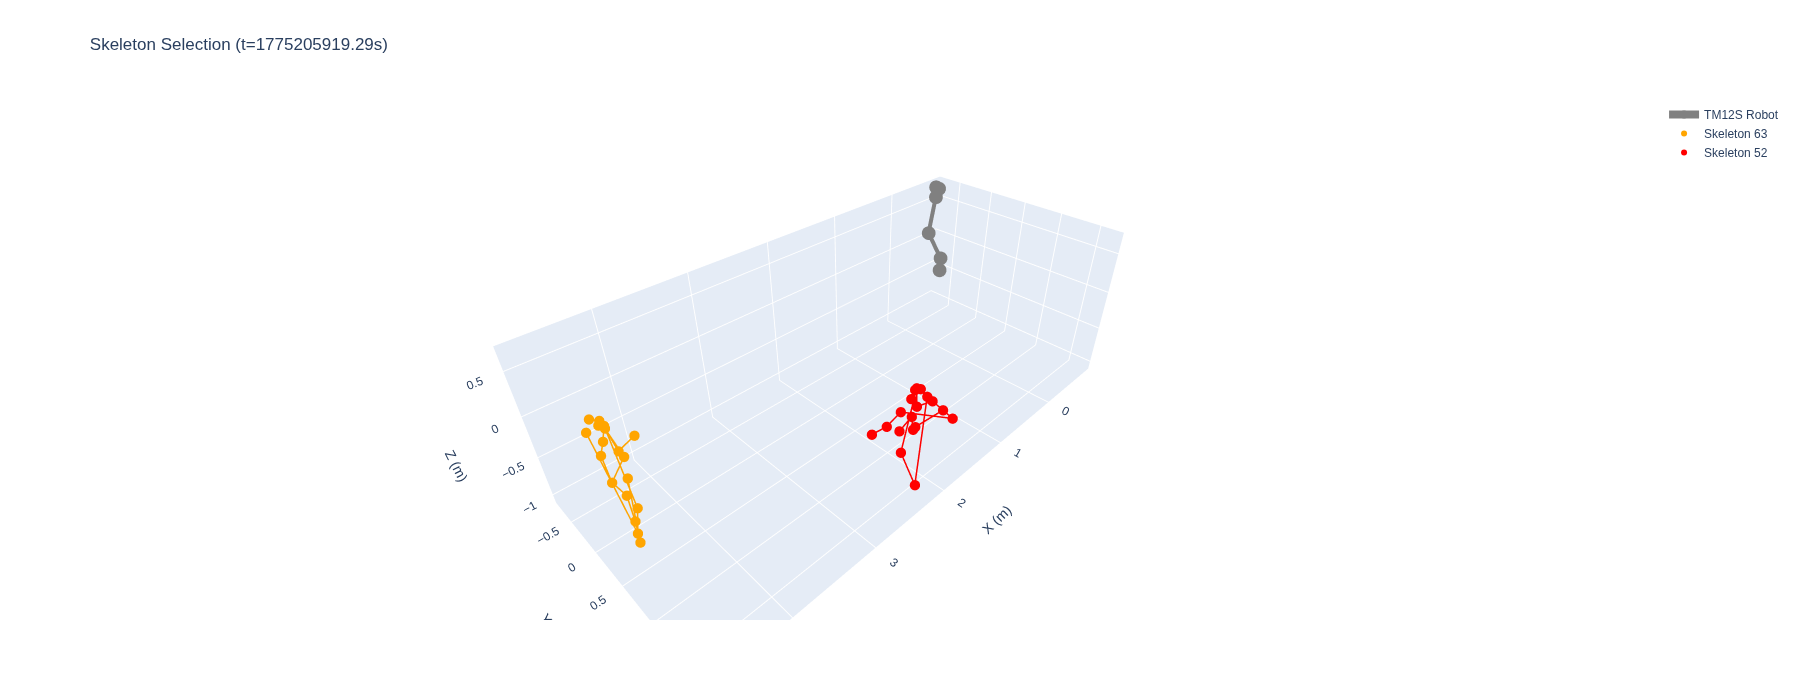

In [46]:
def plot_skeleton_and_robot(
    skeleton_df: pd.DataFrame,
    robot_joint_angles: Dict[str, float],
    fk: ForwardKinematics,
    title: str = "Skeleton Selection"
) -> go.Figure:
    """
    Create 3D plot showing skeletons and robot for selection.
    
    Args:
        skeleton_df: DataFrame with skeleton data (can have multiple skeleton_ids)
        robot_joint_angles: Dictionary of robot joint angles
        fk: Forward kinematics instance
        title: Plot title
    
    Returns:
        Plotly figure
    """
    fig = go.Figure()
    
    # Plot robot
    robot_positions = np.array(fk.get_joint_positions(robot_joint_angles))
    fig.add_trace(go.Scatter3d(
        x=robot_positions[:, 0],
        y=robot_positions[:, 1],
        z=robot_positions[:, 2],
        mode='lines+markers',
        line=dict(color='gray', width=8),
        marker=dict(size=8, color='gray'),
        name='TM12S Robot',
        showlegend=True
    ))
    
    # Plot each skeleton
    colors = ['red', 'blue', 'green', 'orange']  # For up to 4 skeletons
    
    for skeleton_id in skeleton_df['skeleton_id'].unique():
        skel_row = skeleton_df[skeleton_df['skeleton_id'] == skeleton_id].iloc[0]
        
        # Extract keypoint positions
        keypoints = []
        for i in range(18):
            x = skel_row[f'sk_{i}_x']
            y = skel_row[f'sk_{i}_y']
            z = skel_row[f'sk_{i}_z']
            keypoints.append([x, y, z])
        
        keypoints = np.array(keypoints)
        
        # Plot keypoints
        color_idx = int(skeleton_id) % len(colors)
        fig.add_trace(go.Scatter3d(
            x=keypoints[:, 0],
            y=keypoints[:, 1],
            z=keypoints[:, 2],
            mode='markers',
            marker=dict(size=6, color=colors[color_idx]),
            name=f'Skeleton {skeleton_id}',
            showlegend=True
        ))
        
        # Define skeleton connections (ZED 18-point mode)
        connections = [
            (0, 1), (1, 2), (2, 3),  # Spine
            (3, 4), (4, 5), (5, 6), (6, 7),  # Left arm
            (3, 8), (8, 9), (9, 10), (10, 11),  # Right arm
            (0, 12), (12, 13),  # Left leg
            (0, 14), (14, 15),  # Right leg
            (13, 16),  # Left: knee -> point 16
            (15, 17),  # Right: knee -> point 17
        ]
        
        # Plot connections
        for start, end in connections:
            fig.add_trace(go.Scatter3d(
                x=[keypoints[start, 0], keypoints[end, 0]],
                y=[keypoints[start, 1], keypoints[end, 1]],
                z=[keypoints[start, 2], keypoints[end, 2]],
                mode='lines',
                line=dict(color=colors[color_idx], width=3),
                showlegend=False
            ))
    
    # Set layout
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='X (m)',
            yaxis_title='Y (m)',
            zaxis_title='Z (m)',
            aspectmode='data'
        ),
        width=900,
        height=700
    )
    
    return fig


# Get robot joint angles at sample time
sample_joints = df_joints.iloc[(df_joints['timestamp'] - mid_time).abs().argsort()[0]]
sample_joint_angles = {
    fk.joint_names[i]: sample_joints[f'j{i}']
    for i in range(6)
}

# Create visualization
fig = plot_skeleton_and_robot(sample_frame, sample_joint_angles, fk, 
                              f"Skeleton Selection (t={mid_time:.2f}s)")
fig.show()

In [12]:
# =============================================================================
# MANUAL SELECTION - Which skeleton is the leader?
# =============================================================================

SELECTED_SKELETON_ID = 76 # <-- CHANGE THIS AFTER VIEWING VISUALIZATION (options: 5 or 22)

# =============================================================================

print(f"Selected skeleton ID: {SELECTED_SKELETON_ID}")

# Filter to selected skeleton only
df_skeleton_selected = df_skeletons[df_skeletons['skeleton_id'] == SELECTED_SKELETON_ID].copy()
df_skeleton_selected = df_skeleton_selected.drop(columns=['skeleton_id'])
df_skeleton_selected = df_skeleton_selected.reset_index(drop=True)

print(f"\nSelected skeleton data shape: {df_skeleton_selected.shape}")
print(f"Time range: {df_skeleton_selected['timestamp'].min():.2f}s to {df_skeleton_selected['timestamp'].max():.2f}s")

# Validate selection exists throughout recording
time_gaps = df_skeleton_selected['timestamp'].diff()
max_gap = time_gaps.max()
print(f"\nMax time gap in selected skeleton: {max_gap:.3f}s")
if max_gap > 0.5:
    print("WARNING: Large gaps detected - skeleton tracking may be inconsistent")

Selected skeleton ID: 76

Selected skeleton data shape: (4157, 55)
Time range: 1775206320.03s to 1775206598.43s

Max time gap in selected skeleton: 0.074s


## 7. Synchronize Skeleton and Joint Data

Interpolate joint states to skeleton timestamps.

In [13]:
def synchronize_data(
    df_skeleton: pd.DataFrame,
    df_joints: pd.DataFrame,
    tolerance_sec: float = 0.05
) -> pd.DataFrame:
    """
    Synchronize skeleton and joint data by interpolating joints to skeleton timestamps.

    Args:
        df_skeleton: Skeleton DataFrame with timestamp column
        df_joints: Joint DataFrame with timestamp column
        tolerance_sec: Maximum time difference for synchronization

    Returns:
        Synchronized DataFrame with both skeleton and joint data
    """
    # Interpolate each joint column to skeleton timestamps
    joint_cols = [f'j{i}' for i in range(6)]

    interpolated_joints = {}
    for col in joint_cols:
        interpolated_joints[col] = np.interp(
            df_skeleton['timestamp'],
            df_joints['timestamp'],
            df_joints[col]
        )

    # Combine skeleton and interpolated joints
    df_synced = df_skeleton.copy()
    for col, values in interpolated_joints.items():
        df_synced[col] = values

    return df_synced


print("Synchronizing skeleton and joint data...")
# Synchronize ALL skeletons (not just selected one)
df_synced = synchronize_data(df_skeletons, df_joints)

print(f"\nSynchronized data shape: {df_synced.shape}")
print(f"Skeleton IDs in synced data: {df_synced['skeleton_id'].unique()}")
print(f"Columns: {list(df_synced.columns)}")
print(f"\nSample rows:")
print(df_synced[['timestamp', 'skeleton_id', 'sk_0_x', 'sk_0_y', 'sk_0_z', 'j0', 'j1', 'j2']].head())
# Compute end effector pose for each timestamp
print("\nComputing end effector poses...")

ee_positions = []
ee_orientations = []

for idx, row in df_synced.iterrows():
    joint_angles_dict = {fk.joint_names[i]: row[f'j{i}'] for i in range(6)}
    pos, orient = fk.get_end_effector_pose(joint_angles_dict)
    ee_positions.append(pos)
    ee_orientations.append(orient)

ee_positions = np.array(ee_positions)
ee_orientations = np.array(ee_orientations)

# Add to dataframe
df_synced['ee_x'] = ee_positions[:, 0]
df_synced['ee_y'] = ee_positions[:, 1]
df_synced['ee_z'] = ee_positions[:, 2]
df_synced['ee_roll'] = ee_orientations[:, 0]
df_synced['ee_pitch'] = ee_orientations[:, 1]
df_synced['ee_yaw'] = ee_orientations[:, 2]

print(f"✓ Added end effector pose columns (xyz + rpy)")
print(f"  Sample EE position: [{ee_positions[0, 0]:.3f}, {ee_positions[0, 1]:.3f}, {ee_positions[0, 2]:.3f}]")
print(f"  Sample EE orientation (rpy): [{ee_orientations[0, 0]:.3f}, {ee_orientations[0, 1]:.3f}, {ee_orientations[0, 2]:.3f}]")


Synchronizing skeleton and joint data...

Synchronized data shape: (10660, 62)
Skeleton IDs in synced data: [69 70 71 72 73 74 75 76 77 78 79]
Columns: ['timestamp', 'skeleton_id', 'sk_0_x', 'sk_0_y', 'sk_0_z', 'sk_1_x', 'sk_1_y', 'sk_1_z', 'sk_2_x', 'sk_2_y', 'sk_2_z', 'sk_3_x', 'sk_3_y', 'sk_3_z', 'sk_4_x', 'sk_4_y', 'sk_4_z', 'sk_5_x', 'sk_5_y', 'sk_5_z', 'sk_6_x', 'sk_6_y', 'sk_6_z', 'sk_7_x', 'sk_7_y', 'sk_7_z', 'sk_8_x', 'sk_8_y', 'sk_8_z', 'sk_9_x', 'sk_9_y', 'sk_9_z', 'sk_10_x', 'sk_10_y', 'sk_10_z', 'sk_11_x', 'sk_11_y', 'sk_11_z', 'sk_12_x', 'sk_12_y', 'sk_12_z', 'sk_13_x', 'sk_13_y', 'sk_13_z', 'sk_14_x', 'sk_14_y', 'sk_14_z', 'sk_15_x', 'sk_15_y', 'sk_15_z', 'sk_16_x', 'sk_16_y', 'sk_16_z', 'sk_17_x', 'sk_17_y', 'sk_17_z', 'j0', 'j1', 'j2', 'j3', 'j4', 'j5']

Sample rows:
      timestamp  skeleton_id    sk_0_x    sk_0_y    sk_0_z        j0  \
0  1.775206e+09           69  2.265786 -1.640336 -0.692122  0.933824   
1  1.775206e+09           69  2.264920 -1.648593 -0.696422  0

## 8. Transform Skeleton to Robot Frame

Apply static transform from camera frame to robot base frame.

**Note:** This requires the calibrated transform. For now, we'll use a placeholder.
In production, load from `config/camera_to_robot_transform.yaml`.

In [14]:
# Extract static transforms from rosbag
print("Extracting static transforms from /tf_static...")

# Import TF message types
from tf2_msgs.msg import TFMessage

# Get static transforms
tf_static_data = get_topic_messages_with_timestamps(db_file, '/tf_static')
print(f"Found {len(tf_static_data)} /tf_static messages")

# Parse all static transforms
static_transforms = {}

for timestamp_ns, msg_bytes in tf_static_data:
    msg = deserialize_message(msg_bytes, TFMessage)

    for transform in msg.transforms:
        parent = transform.header.frame_id
        child = transform.child_frame_id

        trans = transform.transform.translation
        rot = transform.transform.rotation

        translation = np.array([trans.x, trans.y, trans.z])
        rotation_quat = np.array([rot.x, rot.y, rot.z, rot.w])

        key = f"{parent} -> {child}"
        static_transforms[key] = {
            'parent': parent,
            'child': child,
            'translation': translation,
            'rotation_quat': rotation_quat
        }

print(f"\nFound {len(static_transforms)} unique static transforms:")
for key in static_transforms.keys():
    print(f"  {key}")


Extracting static transforms from /tf_static...
Found 3 /tf_static messages

Found 8 unique static transforms:
  zed_camera_link -> zed_camera_center
  zed_camera_center -> zed_left_camera_frame
  zed_left_camera_frame -> zed_left_camera_frame_optical
  zed_camera_center -> zed_right_camera_frame
  zed_right_camera_frame -> zed_right_camera_frame_optical
  base -> link_0
  link_6 -> flange
  map -> base


In [15]:
# Find the transform from map to base
# (Skeletons are in 'map' frame, need to transform to 'base')
# NOTE: We need the INVERSE of the map->base transform to convert points

camera_to_robot_translation = None
camera_to_robot_rotation = None

# Look for map -> base transform
for key, tf_data in static_transforms.items():
    if tf_data['parent'] == 'map' and tf_data['child'] == 'base':
        # Get the forward transform (map -> base)
        t_forward = tf_data['translation']
        R_forward = quaternion_to_rotation_matrix(tf_data['rotation_quat'])

        print(f"Found transform: map -> base")
        print(f"\nForward transform (map -> base):")
        print(f"  Translation: {t_forward}")
        print(f"  Rotation (quaternion): {tf_data['rotation_quat']}")
        print(f"  Rotation matrix:")
        print(R_forward)

        # Compute INVERSE transform (base -> map)
        # For converting points from map frame to base frame, we need:
        # p_base = R_inv @ (p_map - t_forward)
        # Which is equivalent to: R_inv @ p_map + (-R_inv @ t_forward)

        camera_to_robot_rotation = R_forward.T  # Inverse of rotation is transpose
        camera_to_robot_translation = -camera_to_robot_rotation @ t_forward

        print(f"\nInverse transform (for converting points map -> base):")
        print(f"  Translation: {camera_to_robot_translation}")
        print(f"  Rotation matrix (transposed):")
        print(camera_to_robot_rotation)
        print(f"\n✓ This inverse transform will be applied to skeleton points")
        break

if camera_to_robot_translation is None:
    print("\nWARNING: Could not find 'map -> base' transform in /tf_static")
    print("Using identity transform as fallback")
    camera_to_robot_translation = np.array([0.0, 0.0, 0.0])
    camera_to_robot_rotation = np.eye(3)
else:
    print(f"\n✓ Will use inverse transform to convert skeletons from map frame to base frame")


Found transform: map -> base

Forward transform (map -> base):
  Translation: [ 3.6  -0.27 -0.25]
  Rotation (quaternion): [0.00000000e+00 0.00000000e+00 9.99999683e-01 7.96326711e-04]
  Rotation matrix:
[[-0.99999873 -0.00159265  0.        ]
 [ 0.00159265 -0.99999873  0.        ]
 [ 0.          0.          1.        ]]

Inverse transform (for converting points map -> base):
  Translation: [ 3.60042545 -0.26426611  0.25      ]
  Rotation matrix (transposed):
[[-0.99999873  0.00159265  0.        ]
 [-0.00159265 -0.99999873  0.        ]
 [ 0.          0.          1.        ]]

✓ This inverse transform will be applied to skeleton points

✓ Will use inverse transform to convert skeletons from map frame to base frame


In [16]:
def apply_transform_to_skeleton(
    df: pd.DataFrame,
    translation: np.ndarray,
    rotation_matrix: np.ndarray
) -> pd.DataFrame:
    """
    Apply rigid transform to all skeleton keypoints.

    Args:
        df: DataFrame with skeleton keypoints (sk_i_x, sk_i_y, sk_i_z)
        translation: 3D translation vector
        rotation_matrix: 3x3 rotation matrix

    Returns:
        DataFrame with transformed skeleton keypoints
    """
    df_transformed = df.copy()

    for i in range(18):
        # Extract keypoint
        x = df[f'sk_{i}_x'].values
        y = df[f'sk_{i}_y'].values
        z = df[f'sk_{i}_z'].values

        # Apply rotation and translation
        keypoints = np.stack([x, y, z], axis=1)  # [N, 3]
        keypoints_transformed = (rotation_matrix @ keypoints.T).T + translation

        # Update DataFrame
        df_transformed[f'sk_{i}_x'] = keypoints_transformed[:, 0]
        df_transformed[f'sk_{i}_y'] = keypoints_transformed[:, 1]
        df_transformed[f'sk_{i}_z'] = keypoints_transformed[:, 2]

    return df_transformed


In [17]:
# Apply the extracted transform to all skeletons
print("Applying coordinate transform to skeleton...")
print(f"Transform: map -> base")
print(f"  Translation: {camera_to_robot_translation}")
print(f"  Rotation matrix shape: {camera_to_robot_rotation.shape}")

# Transform ALL skeletons (both detected skeletons)
df_synced_transformed = apply_transform_to_skeleton(
    df_synced,
    camera_to_robot_translation,
    camera_to_robot_rotation
)

print(f"\nTransform applied successfully")
print(f"Transformed data shape: {df_synced_transformed.shape}")
print(f"Skeleton IDs after transform: {df_synced_transformed['skeleton_id'].unique()}")

Applying coordinate transform to skeleton...
Transform: map -> base
  Translation: [ 3.60042545 -0.26426611  0.25      ]
  Rotation matrix shape: (3, 3)

Transform applied successfully
Transformed data shape: (10660, 68)
Skeleton IDs after transform: [69 70 71 72 73 74 75 76 77 78 79]


## 8.1 Visualize Transformed Skeletons with RGB Image

Verify both skeletons are correctly transformed before selecting one for export.

**Change `VISUALIZATION_FRAME_INDEX` below to explore different frames.**

In [18]:
# Extract RGB images from rosbag (do this once)
from sensor_msgs.msg import Image
from cv_bridge import CvBridge
import cv2

print("Loading RGB images from rosbag...")
rgb_data = get_topic_messages_with_timestamps(db_file, '/zed/zed_node/rgb/color/rect/image')
print(f"Found {len(rgb_data)} RGB images")

# Create a bridge to convert ROS images to OpenCV format
bridge = CvBridge()

# Parse RGB images into a list with timestamps
rgb_images = []
for timestamp_ns, msg_bytes in rgb_data:
    msg = deserialize_message(msg_bytes, Image)
    rgb_images.append({
        'timestamp': timestamp_to_seconds(timestamp_ns),
        'image': msg
    })

print(f"✓ Parsed {len(rgb_images)} RGB images")

# Get valid frame indices
valid_indices = df_synced_transformed.groupby('timestamp').size()
max_frame_index = len(valid_indices) - 1

print(f"✓ Frame range: 0 to {max_frame_index}")
print("\n" + "="*60)
print("Interactive slider will appear in the next cell ↓")
print("="*60)


Loading RGB images from rosbag...
Found 5431 RGB images
✓ Parsed 5431 RGB images
✓ Frame range: 0 to 5430

Interactive slider will appear in the next cell ↓


In [19]:
# Interactive visualization with slider
def visualize_frame(frame_index):
    """Visualize a specific frame with RGB image and 3D skeletons"""

    if len(df_synced_transformed) == 0:
        print("WARNING: No data to visualize")
        return

    # Get the frame at this index
    valid_indices = df_synced_transformed.groupby('timestamp').size()

    if frame_index >= len(valid_indices):
        frame_index = len(valid_indices) - 1

    sample_time = valid_indices.index[frame_index]
    sample_data = df_synced_transformed[df_synced_transformed['timestamp'] == sample_time]

    # Find closest RGB image
    time_diffs = [abs(img['timestamp'] - sample_time) for img in rgb_images]
    closest_idx = time_diffs.index(min(time_diffs))
    closest_rgb = rgb_images[closest_idx]

    # Convert ROS image to numpy array
    cv_image = bridge.imgmsg_to_cv2(closest_rgb['image'], desired_encoding='rgb8')

    # Get robot joint angles
    sample_row = sample_data.iloc[0]
    robot_joint_angles = {fk.joint_names[i]: sample_row[f'j{i}'] for i in range(6)}
    robot_positions = np.array(fk.get_joint_positions(robot_joint_angles))

    # Create visualization
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "xy"}, {"type": "scene"}]],
        column_widths=[0.5, 0.5],
        subplot_titles=('RGB Image', 'Transformed Skeletons')
    )

    # Add RGB image
    fig.add_trace(go.Image(z=cv_image), row=1, col=1)

    # Plot robot
    fig.add_trace(go.Scatter3d(
        x=robot_positions[:, 0], y=robot_positions[:, 1], z=robot_positions[:, 2],
        mode='lines+markers',
        line=dict(color='gray', width=8),
        marker=dict(size=8, color='gray'),
        name='TM12S Robot'
    ), row=1, col=2)

    # Plot skeletons
    colors = ['red', 'blue', 'green', 'orange']
    for idx, (_, skel_row) in enumerate(sample_data.iterrows()):
        skeleton_id = skel_row['skeleton_id']
        skeleton_keypoints = np.array([[skel_row[f'sk_{i}_x'], skel_row[f'sk_{i}_y'], skel_row[f'sk_{i}_z']] for i in range(18)])
        color = colors[int(skeleton_id) % len(colors)]

        fig.add_trace(go.Scatter3d(
            x=skeleton_keypoints[:, 0], y=skeleton_keypoints[:, 1], z=skeleton_keypoints[:, 2],
            mode='markers', marker=dict(size=8, color=color),
            name=f'Skeleton {skeleton_id}'
        ), row=1, col=2)


        # Skeleton connections
        connections = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(3,8),(8,9),(9,10),(10,11),(0,12),(12,13),(0,14),(14,15),(13,16),(15,17)]
        for start, end in connections:
            fig.add_trace(go.Scatter3d(
                x=[skeleton_keypoints[start,0], skeleton_keypoints[end,0]],
                y=[skeleton_keypoints[start,1], skeleton_keypoints[end,1]],
                z=[skeleton_keypoints[start,2], skeleton_keypoints[end,2]],
                mode='lines', line=dict(color=color, width=3),
                showlegend=False
            ), row=1, col=2)

    # Coordinate axes
    axis_length = 0.5
    fig.add_trace(go.Scatter3d(x=[0,axis_length], y=[0,0], z=[0,0], mode='lines', line=dict(color='red', width=4), name='X-axis'), row=1, col=2)
    fig.add_trace(go.Scatter3d(x=[0,0], y=[0,axis_length], z=[0,0], mode='lines', line=dict(color='green', width=4), name='Y-axis'), row=1, col=2)
    fig.add_trace(go.Scatter3d(x=[0,0], y=[0,0], z=[0,axis_length], mode='lines', line=dict(color='blue', width=4), name='Z-axis'), row=1, col=2)

    # Layout
    fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False, row=1, col=1)
    fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False, row=1, col=1)
    fig.update_layout(
        title_text=f'Frame {frame_index}/{max_frame_index} | t={sample_time:.2f}s | Skeletons: {len(sample_data)}',
        scene=dict(xaxis_title='X (m)', yaxis_title='Y (m)', zaxis_title='Z (m)', aspectmode='data',
                   camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))),
        width=1600, height=700, showlegend=True
    )
    fig.show()

# Create interactive slider
print("🎬 Drag the slider to scrub through frames:")
interact(
    visualize_frame,
    frame_index=IntSlider(min=0, max=max_frame_index, step=1, value=max_frame_index//2,
                         description='Frame:', style={'description_width': '60px'},
                         layout=Layout(width='800px'))
);


🎬 Drag the slider to scrub through frames:


interactive(children=(IntSlider(value=2715, description='Frame:', layout=Layout(width='800px'), max=5430, styl…

## 8.2 Filter to Selected Skeleton

After verifying both transformed skeletons, filter to the selected skeleton for export.

In [20]:
# Filter to selected skeleton only (for CSV export)
print(f"Filtering to selected skeleton ID: {SELECTED_SKELETON_ID}")

df_synced_transformed_selected = df_synced_transformed[
    df_synced_transformed['skeleton_id'] == SELECTED_SKELETON_ID
].copy()

# Drop skeleton_id column (no longer needed)
df_synced_transformed_selected = df_synced_transformed_selected.drop(columns=['skeleton_id'])
df_synced_transformed_selected = df_synced_transformed_selected.reset_index(drop=True)

print(f"\nFiltered data shape: {df_synced_transformed_selected.shape}")
print(f"Time range: {df_synced_transformed_selected['timestamp'].min():.2f}s to {df_synced_transformed_selected['timestamp'].max():.2f}s")
print(f"Number of frames: {len(df_synced_transformed_selected)}")


Filtering to selected skeleton ID: 76

Filtered data shape: (4157, 67)
Time range: 1775206320.03s to 1775206598.43s
Number of frames: 4157


## 9. Quality Checks

In [21]:
def quality_checks(df: pd.DataFrame, fk: ForwardKinematics) -> Dict[str, Any]:
    """
    Perform quality checks on synchronized data.

    Returns:
        Dictionary with quality metrics
    """
    metrics = {}

    # Check if DataFrame is empty
    if len(df) == 0:
        metrics['nan_count'] = 0
        metrics['max_pelvis_speed'] = 0
        metrics['mean_pelvis_speed'] = 0
        metrics['jumps_over_2ms'] = 0
        metrics['joint_limit_violations'] = 0
        metrics['num_samples'] = 0
        metrics['duration_sec'] = 0
        metrics['avg_frequency_hz'] = 0
        print("WARNING: Empty DataFrame - no data to analyze")
        return metrics

    # 1. Check for NaN values
    metrics['nan_count'] = df.isna().sum().sum()

    # 2. Check for position jumps in skeleton
    pelvis_positions = df[['sk_0_x', 'sk_0_y', 'sk_0_z']].values

    if len(pelvis_positions) > 1:
        pelvis_velocity = np.linalg.norm(np.diff(pelvis_positions, axis=0), axis=1)
        time_diffs = np.diff(df['timestamp'].values)
        pelvis_speed = pelvis_velocity / np.maximum(time_diffs, 1e-6)  # Avoid division by zero

        metrics['max_pelvis_speed'] = pelvis_speed.max()
        metrics['mean_pelvis_speed'] = pelvis_speed.mean()
        metrics['jumps_over_2ms'] = (pelvis_speed > 2.0).sum()  # 2 m/s threshold
    else:
        metrics['max_pelvis_speed'] = 0
        metrics['mean_pelvis_speed'] = 0
        metrics['jumps_over_2ms'] = 0

    # 3. Check joint limits
    joint_limit_violations = 0
    for i, joint_name in enumerate(fk.joint_names):
        limits = fk.joint_info[joint_name]['limits']
        joint_values = df[f'j{i}'].values
        violations = ((joint_values < limits[0]) | (joint_values > limits[1])).sum()
        joint_limit_violations += violations

    metrics['joint_limit_violations'] = joint_limit_violations

    # 4. Check temporal consistency
    metrics['num_samples'] = len(df)
    if len(df) > 1:
        metrics['duration_sec'] = df['timestamp'].max() - df['timestamp'].min()
        metrics['avg_frequency_hz'] = metrics['num_samples'] / metrics['duration_sec'] if metrics['duration_sec'] > 0 else 0
    else:
        metrics['duration_sec'] = 0
        metrics['avg_frequency_hz'] = 0

    return metrics


print("Performing quality checks...\n")
quality_metrics = quality_checks(df_synced_transformed_selected, fk)

print("Quality Metrics:")
print("=" * 50)
for key, value in quality_metrics.items():
    print(f"{key:30s}: {value}")
print("=" * 50)

# Warnings
if quality_metrics['nan_count'] > 0:
    print(f"\nWARNING: {quality_metrics['nan_count']} NaN values detected")

if quality_metrics['jumps_over_2ms'] > 0:
    print(f"\nWARNING: {quality_metrics['jumps_over_2ms']} large position jumps detected")

if quality_metrics['joint_limit_violations'] > 0:
    print(f"\nWARNING: {quality_metrics['joint_limit_violations']} joint limit violations detected")

Performing quality checks...

Quality Metrics:
nan_count                     : 72
max_pelvis_speed              : nan
mean_pelvis_speed             : nan
jumps_over_2ms                : 49
joint_limit_violations        : 0
num_samples                   : 4157
duration_sec                  : 278.3959994316101
avg_frequency_hz              : 14.9319674438109




## 10. Export to CSV

Export the **selected skeleton only** (transformed to robot frame) with synchronized joint states.

In [22]:
# =============================================================================
# CSV EXPORT - What gets saved
# =============================================================================
#
# This cell exports the SELECTED SKELETON ONLY (not both skeletons)
#
# CSV Structure:
# ---------------
# - 1 timestamp column:  timestamp (seconds since epoch)
# - 54 skeleton columns: sk_0_x, sk_0_y, sk_0_z, ..., sk_17_x, sk_17_y, sk_17_z
#                        (18 keypoints × 3 coordinates each)
# - 6 joint columns:     j0, j1, j2, j3, j4, j5 (robot joint angles in radians)
# - 6 end effector cols: ee_x, ee_y, ee_z, ee_roll, ee_pitch, ee_yaw
#                        (position in meters, orientation in radians)
#
# Total: 61 columns per row
#
# Coordinate Frames:
# ------------------
# - Skeleton keypoints: Transformed to robot base frame (not camera frame)
# - Joint angles: TM12S joint angles synchronized to skeleton timestamps
#
# Skeleton Keypoint Order (ZED Body 18-point model):
# ---------------------------------------------------
# 0: Pelvis          8: Right shoulder
# 1: Naval spine     9: Right elbow
# 2: Chest          10: Right wrist
# 3: Neck           11: Right hand
# 4: Left shoulder  12: Left hip
# 5: Left elbow     13: Left knee
# 6: Left wrist     14: Right hip
# 7: Left hand      15: Right knee
#
# =============================================================================

# Determine next recording ID
if metadata_file.exists():
    df_metadata = pd.read_csv(metadata_file)
    next_rec_id = df_metadata['recording_id'].max() + 1
else:
    next_rec_id = 1
    df_metadata = pd.DataFrame()

# Use rosbag name for CSV filename (easier to track)
csv_filename = f"{ROSBAG_NAME}.csv"
csv_output_path = csv_output_dir / csv_filename

print(f"Recording ID: {next_rec_id}")
print(f"Output CSV: {csv_output_path}")

# Reorder columns for CSV export
skeleton_cols = [f'sk_{i}_{axis}' for i in range(18) for axis in ['x', 'y', 'z']]
joint_cols = [f'j{i}' for i in range(6)]
ee_cols = ['ee_x', 'ee_y', 'ee_z', 'ee_roll', 'ee_pitch', 'ee_yaw']
export_cols = ['timestamp'] + skeleton_cols + joint_cols + ee_cols

# Use the FILTERED dataframe (selected skeleton only)
df_export = df_synced_transformed_selected[export_cols]

print(f"\nExporting SELECTED skeleton only (ID: {SELECTED_SKELETON_ID})")
print(f"  Rows: {len(df_export)}")
print(f"  Columns: {len(df_export.columns)}")
print(f"    - 1 timestamp column")
print(f"    - 54 skeleton columns (18 keypoints × 3 coords)")
# - 6 joint angle columns
# - 6 end effector columns (xyz + rpy)

# Save CSV
df_export.to_csv(csv_output_path, index=False)
print(f"\n✓ Exported {len(df_export)} rows to {csv_output_path}")
print(f"✓ CSV size: {csv_output_path.stat().st_size / 1024 / 1024:.2f} MB")

# Display sample
print(f"\nSample of exported data:")
print(df_export.head(3))


Recording ID: 27
Output CSV: /data/processed/csv/26_04_03_RAPP_M_R2G4_01.csv

Exporting SELECTED skeleton only (ID: 76)
  Rows: 4157
  Columns: 67
    - 1 timestamp column
    - 54 skeleton columns (18 keypoints × 3 coords)

✓ Exported 4157 rows to /data/processed/csv/26_04_03_RAPP_M_R2G4_01.csv
✓ CSV size: 5.11 MB

Sample of exported data:
      timestamp   sk_0_x    sk_0_y    sk_0_z    sk_1_x    sk_1_y    sk_1_z  \
0  1.775206e+09      NaN       NaN       NaN -0.688554  2.858781  0.007956   
1  1.775206e+09      NaN       NaN       NaN  0.342209  2.193771  0.064641   
2  1.775206e+09  1.14272  1.255279  0.163376  1.382455  1.360401  0.132511   

     sk_2_x    sk_2_y    sk_2_z  ...        j2        j3        j4        j5  \
0 -0.688645  2.837566  0.012984  ...  1.573241 -1.723556  1.528165  0.033515   
1  0.393551  2.144755  0.067899  ...  1.573394 -1.721947  1.528179  0.033512   
2  1.444899  1.321355  0.121919  ...  1.573387 -1.715501  1.528178  0.033507   

       ee_x      ee_y  

## 11. Update Metadata

In [23]:
# Create metadata entry
metadata_entry = {
    'recording_id': next_rec_id,
    'csv_filename': csv_filename,
    'rosbag_name': ROSBAG_NAME,
    'selected_skeleton_id': SELECTED_SKELETON_ID,
    'num_samples': len(df_export),
    'duration_sec': quality_metrics['duration_sec'],
    'avg_frequency_hz': quality_metrics['avg_frequency_hz'],
    'processed_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'quality_nan_count': quality_metrics['nan_count'],
    'quality_jumps': quality_metrics['jumps_over_2ms'],
    'quality_joint_violations': quality_metrics['joint_limit_violations']
}

# Append to metadata file
df_metadata_new = pd.DataFrame([metadata_entry])
if metadata_file.exists():
    df_metadata = pd.concat([df_metadata, df_metadata_new], ignore_index=True)
else:
    df_metadata = df_metadata_new

df_metadata.to_csv(metadata_file, index=False)
print(f"\nUpdated metadata file: {metadata_file}")
print(f"\nMetadata entry:")
print(df_metadata_new.T)


Updated metadata file: /data/processed/recordings_metadata.csv

Metadata entry:
                                                    0
recording_id                                       27
csv_filename              26_04_03_RAPP_M_R2G4_01.csv
rosbag_name                   26_04_03_RAPP_M_R2G4_01
selected_skeleton_id                               76
num_samples                                      4157
duration_sec                               278.395999
avg_frequency_hz                            14.931967
processed_date                    2026-04-04 01:55:48
quality_nan_count                                  72
quality_jumps                                      49
quality_joint_violations                            0


## 12. Summary

In [24]:
print("=" * 70)
print("PHASE 2 PROCESSING COMPLETE")
print("=" * 70)

print(f"\nRosbag: {ROSBAG_NAME}")
print(f"Recording ID: {next_rec_id}")
print(f"Selected Skeleton: {SELECTED_SKELETON_ID}")
print(f"\nOutput:")
print(f"  CSV: {csv_output_path}")
print(f"  Rows: {len(df_export)}")
print(f"  Columns: {len(df_export.columns)}")
print(f"  Duration: {quality_metrics['duration_sec']:.2f}s")
print(f"  Frequency: {quality_metrics['avg_frequency_hz']:.1f} Hz")

print(f"\nQuality:")
print(f"  NaN values: {quality_metrics['nan_count']}")
print(f"  Position jumps: {quality_metrics['jumps_over_2ms']}")
print(f"  Joint violations: {quality_metrics['joint_limit_violations']}")

print("\n" + "=" * 70)
print("NEXT STEPS")
print("=" * 70)
print("""
1. Change ROSBAG_NAME at the top of this notebook to process the next rosbag
2. Run the notebook again to process additional recordings
3. Once all rosbags are processed, proceed to:
   - 02_prepare_training_data.ipynb: Create PyTorch datasets
   - 03_train_vam.ipynb: Train the Vision-Action Model
""")

print("=" * 70)

PHASE 2 PROCESSING COMPLETE

Rosbag: 26_04_03_RAPP_M_R2G4_01
Recording ID: 27
Selected Skeleton: 76

Output:
  CSV: /data/processed/csv/26_04_03_RAPP_M_R2G4_01.csv
  Rows: 4157
  Columns: 67
  Duration: 278.40s
  Frequency: 14.9 Hz

Quality:
  NaN values: 72
  Position jumps: 49
  Joint violations: 0

NEXT STEPS

1. Change ROSBAG_NAME at the top of this notebook to process the next rosbag
2. Run the notebook again to process additional recordings
3. Once all rosbags are processed, proceed to:
   - 02_prepare_training_data.ipynb: Create PyTorch datasets
   - 03_train_vam.ipynb: Train the Vision-Action Model

